🌀 Möbius Traversal Comparison: Continuous vs. Discrete
Output directory: mobius_results
------------------------------------------------------------
Generating continuous traversal...
Generating discrete traversal (coarse)...
Generating discrete traversal (fine)...
✓ Saved CSV data files

📊 Traversal Structure Scores:
  Continuous (ideal):     0.55
  Discrete (coarse):      0.55
  Discrete (fine):        0.55
  → Difference: 0.00 (continuous appears more structured)
  → But discrete reveals the computational boundary!

🎨 Generating figures...
✓ Saved 3D comparison: mobius_results/fig1_3d_comparison.png
✓ Saved stagnation analysis: mobius_results/fig2_stagnation_analysis.png
✓ Saved structure score comparison: mobius_results/fig3_structure_scores.png

✅ Complete. Results saved to: mobius_results/

📝 Key Takeaways for Paper #2:
  • 'Infinite' traversal is a continuum idealization
  • Discrete instantiation always hits a precision/physical cutoff
  • Structure scores quantify the mapping-

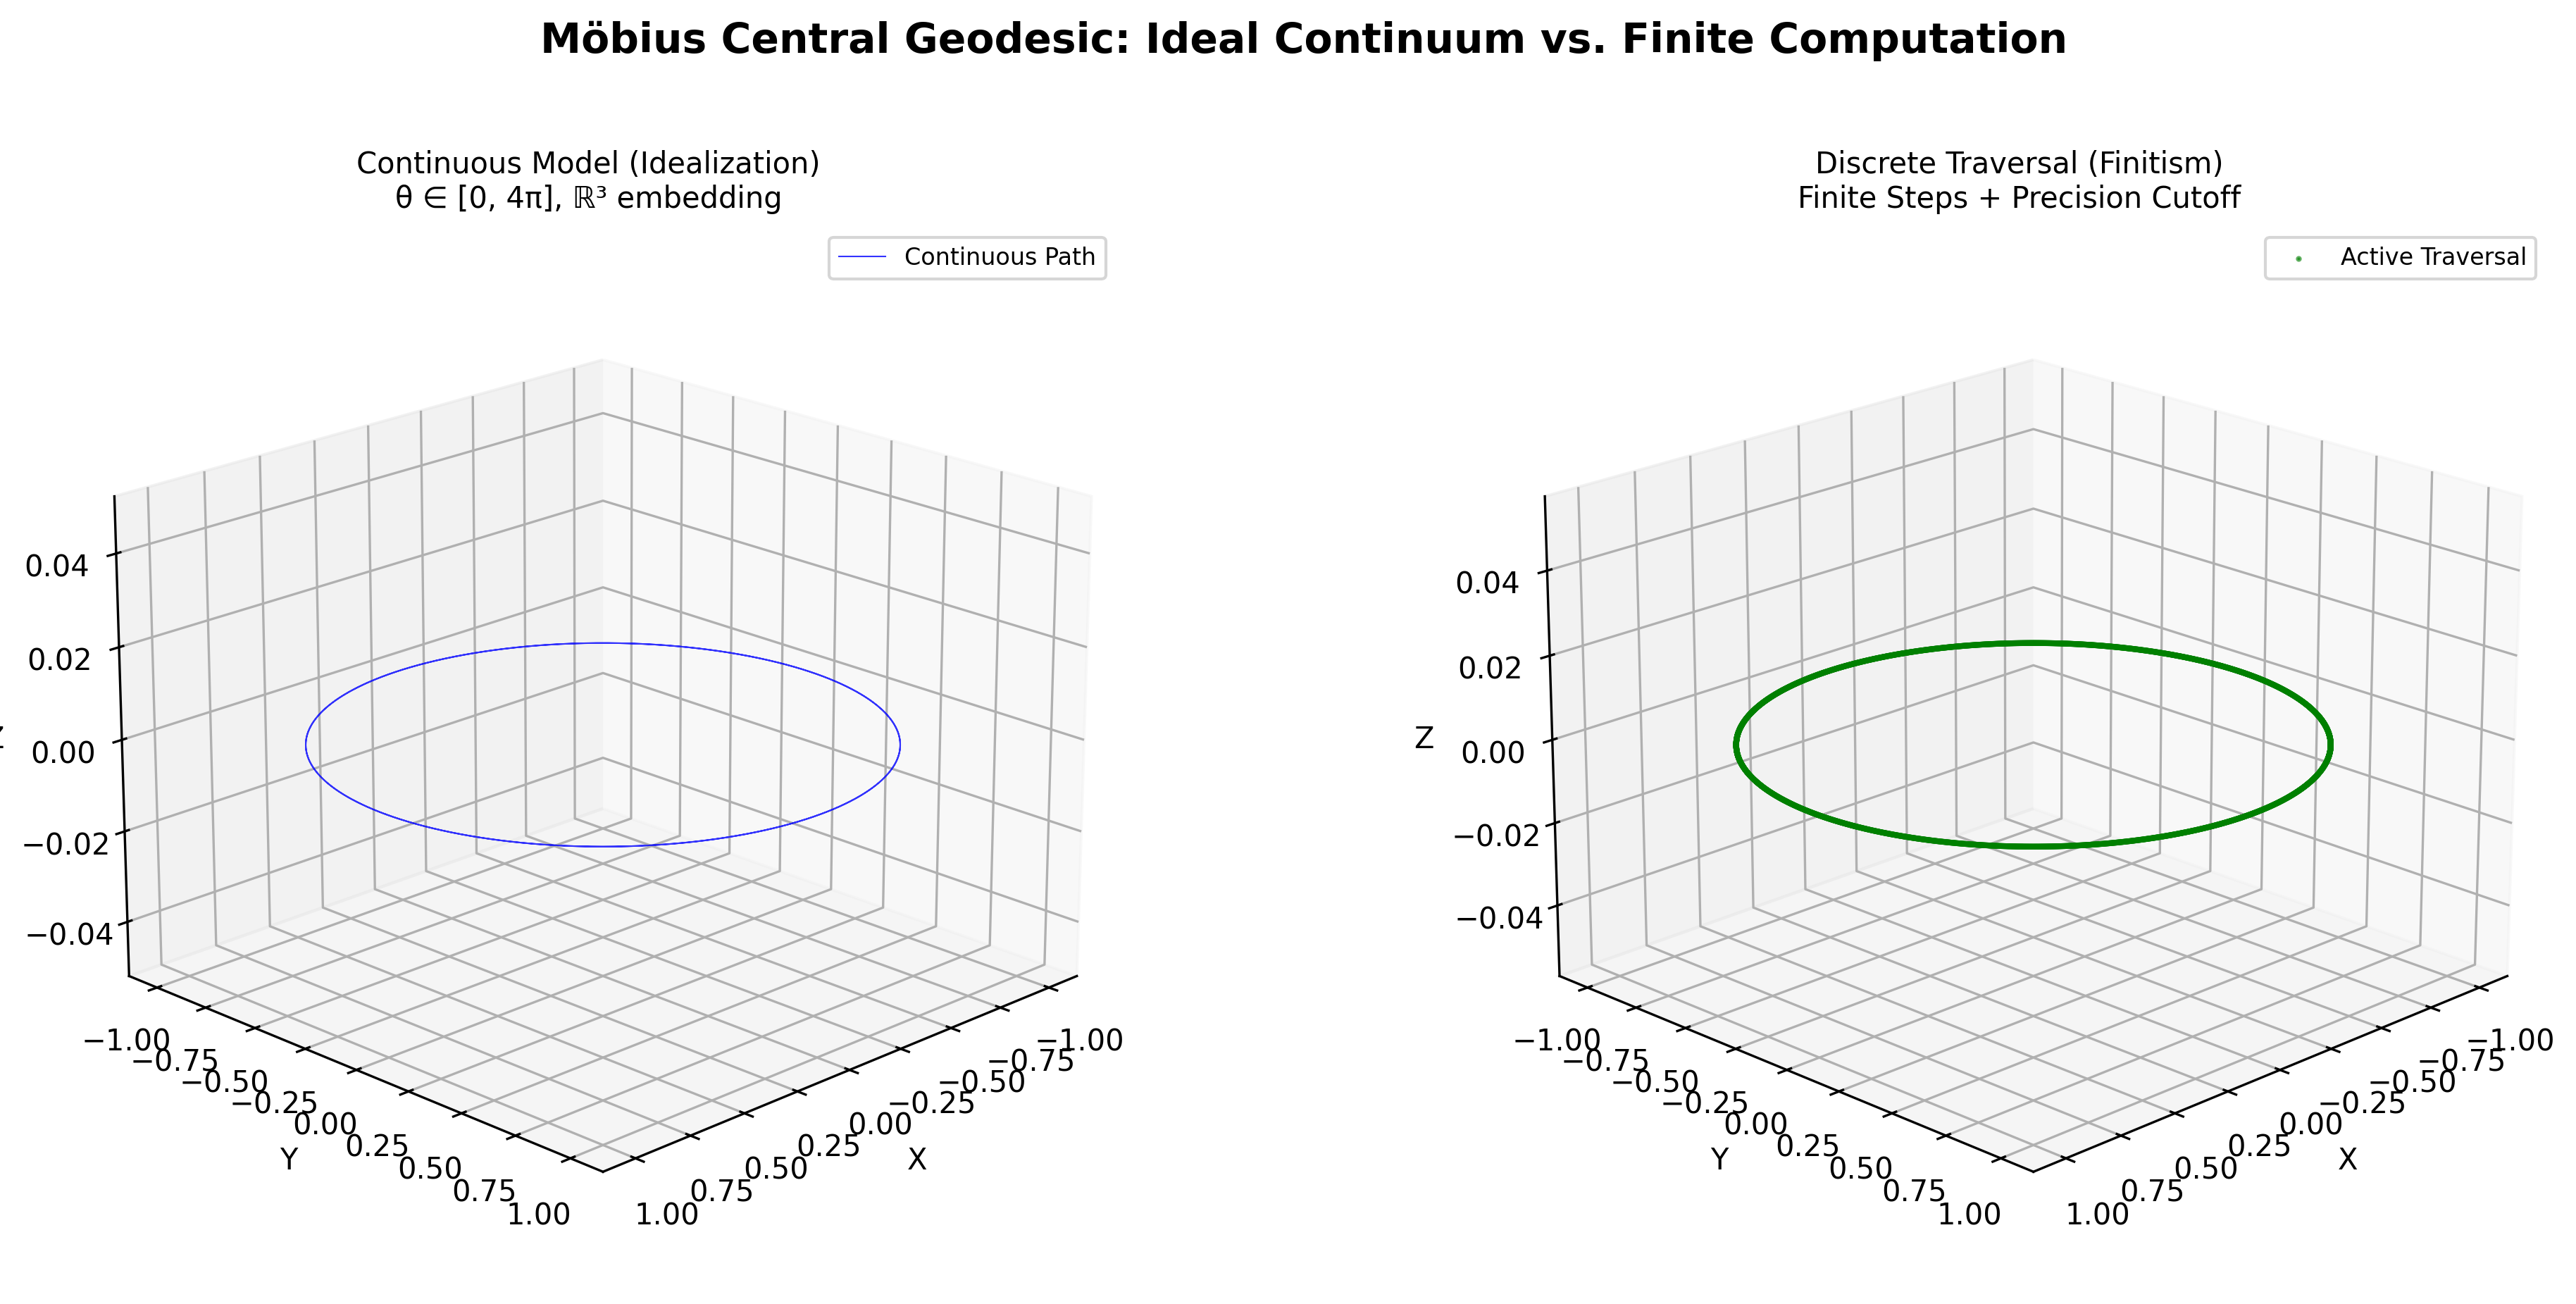

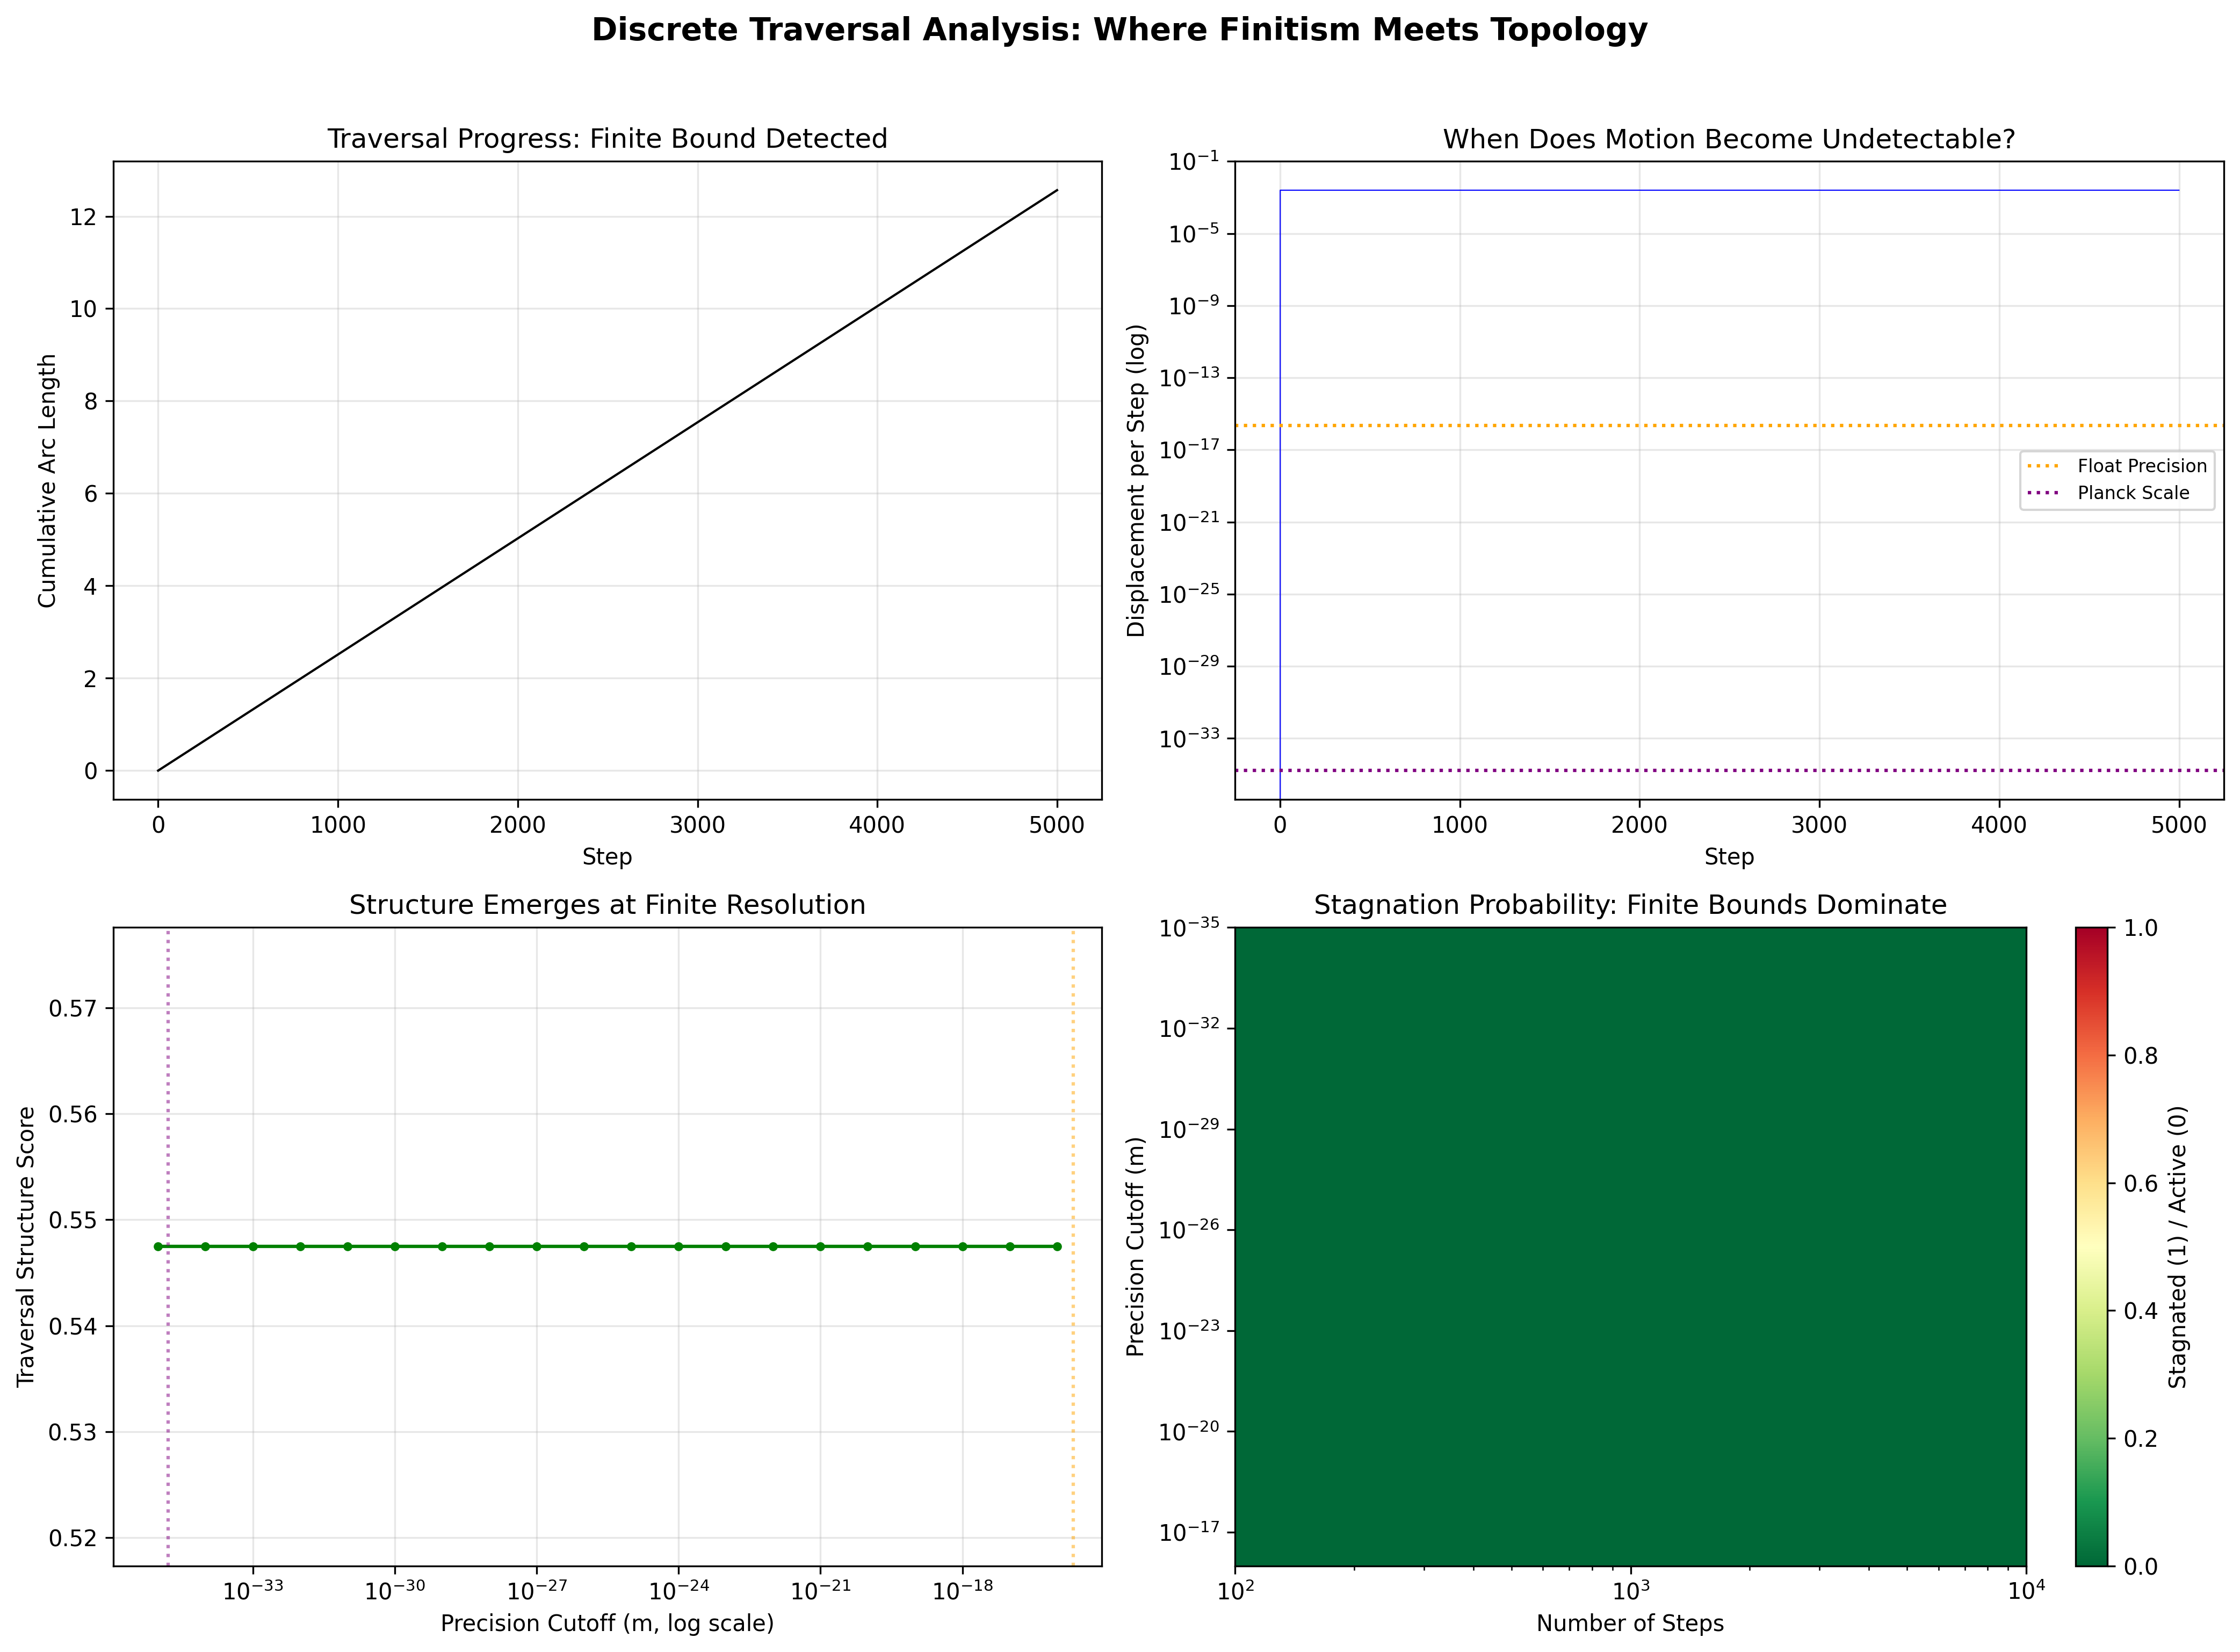

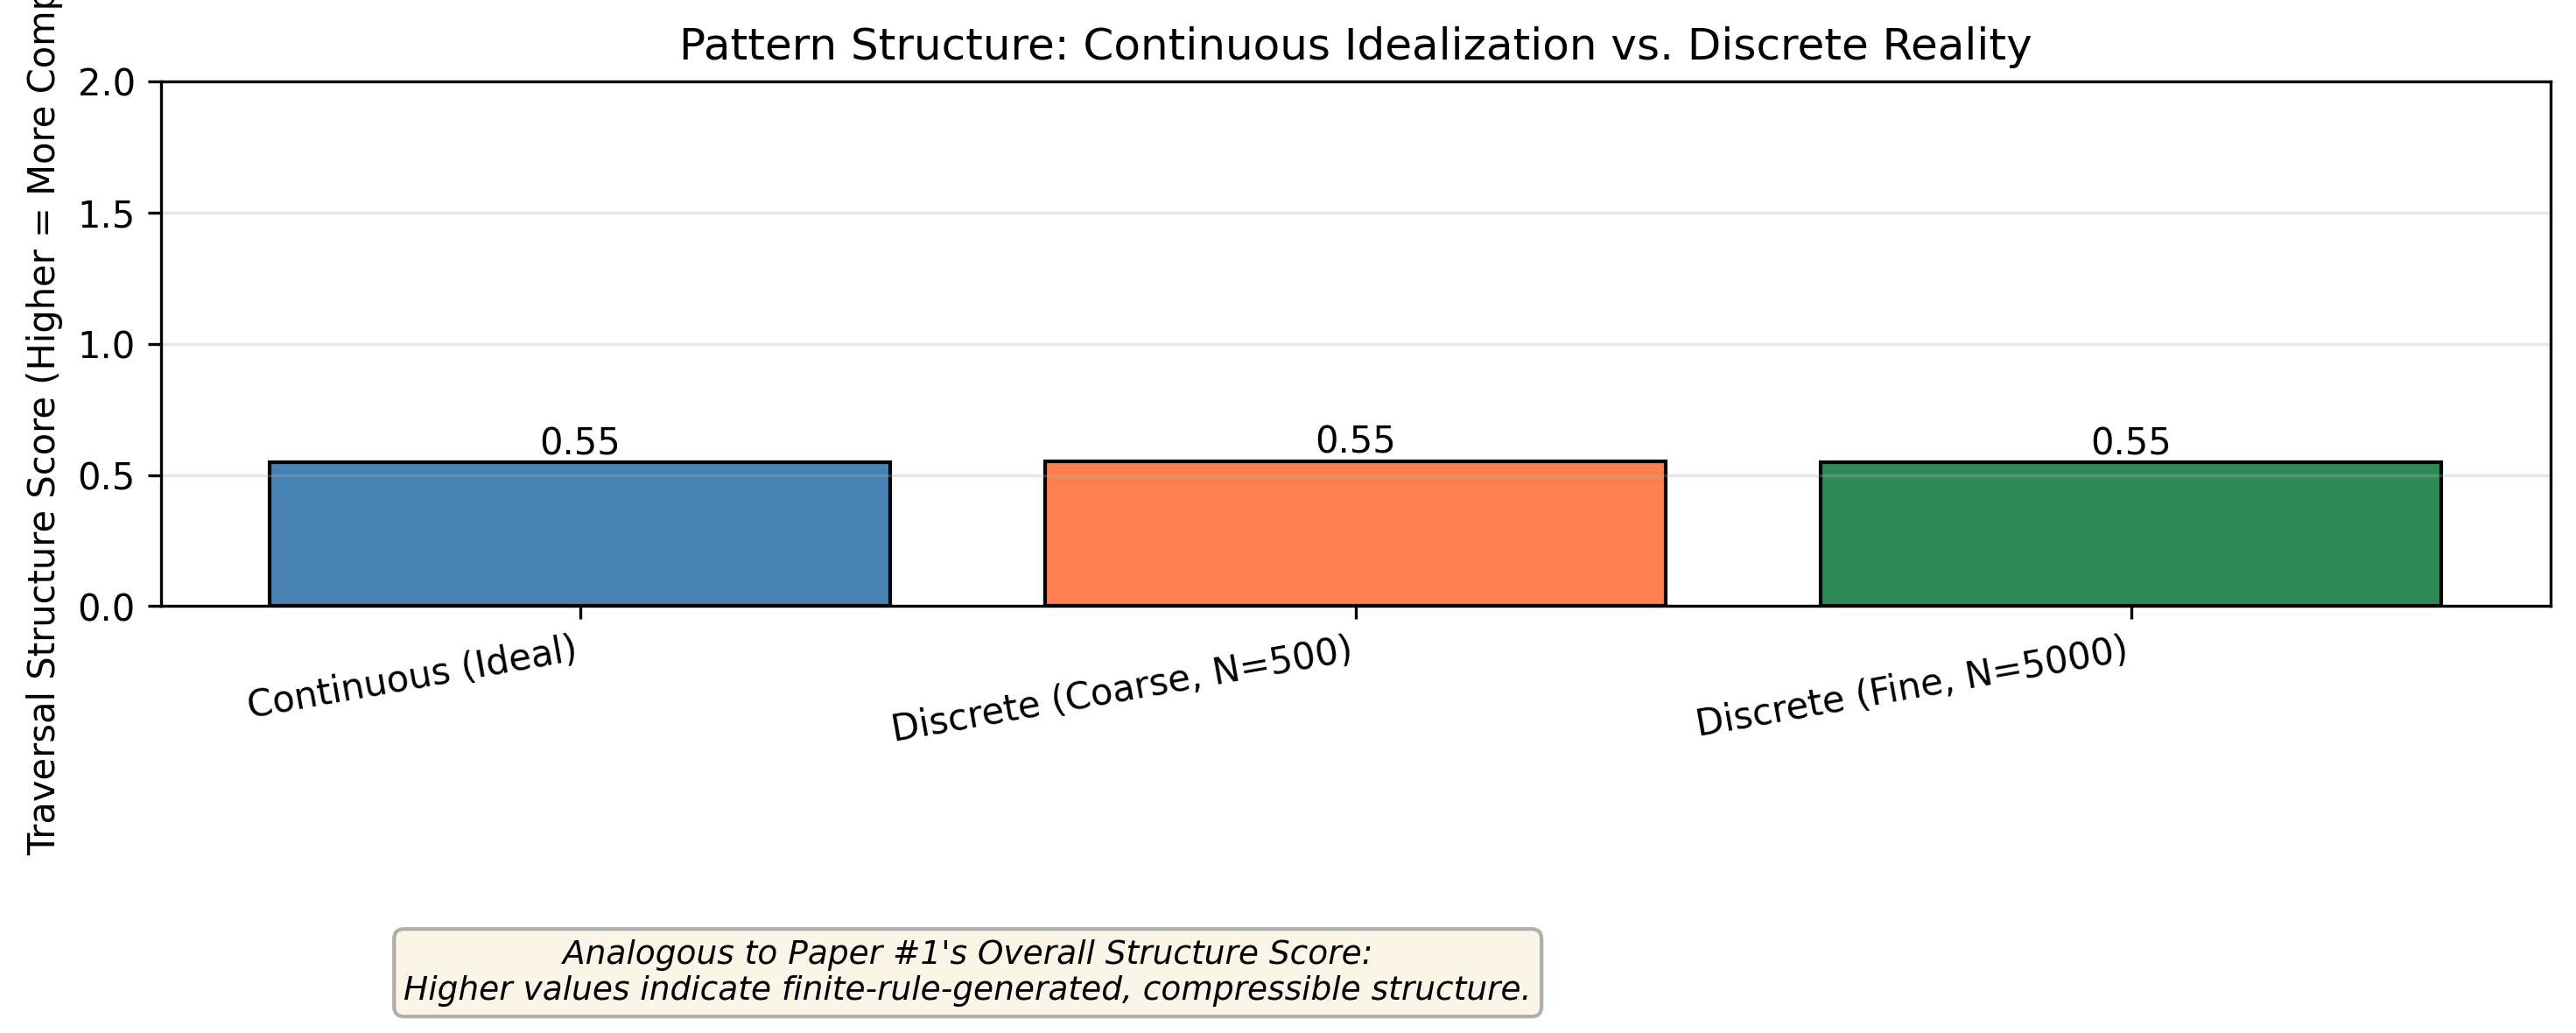

In [ ]:
"""
mobius_traversal_comparison.py
==============================
Continuous vs. Discrete Traversal of the Möbius Strip
Demonstrates computational finitism: "infinite" paths hit finite bounds.

For Paper #2: "The Physical Singularity: When Finitism Meets the Event Horizon"
Author: Néstor E. Ramos
Collaborator: Rosana Augusto de Souza Ramos
Date: March 2026
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import Tuple, List, Optional, Callable
import pandas as pd
import warnings
import os

# ============================================================================
# CONFIGURATION (Easy to modify for reproducibility)
# ============================================================================
CONFIG = {
    "output_dir": "mobius_results",
    "n_steps_continuous": 10000,      # High-res "ideal" traversal
    "n_steps_discrete_low": 500,      # Coarse discrete (visible jitter)
    "n_steps_discrete_high": 5000,    # Fine discrete (near-continuous)
    "planck_scale": 1.616e-35,         # Hypothetical physical cutoff (m)
    "float_precision": np.finfo(float).eps,  # ~2.2e-16
    "width": 1.0,                      # Möbius strip half-width
    "radius": 1.0,                     # Central radius
    "save_figs": True,
    "save_csv": True,
    "dpi": 300,
}

# Create output directory
os.makedirs(CONFIG["output_dir"], exist_ok=True)


# ============================================================================
# MÖBIUS STRIP PARAMETRIC EQUATIONS
# ============================================================================
def mobius_parametric(u: np.ndarray, v: np.ndarray,
                      radius: float = 1.0, width: float = 1.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Standard parametric equations for Möbius strip.

    Parameters:
    -----------
    u : array_like
        Angular parameter [0, 2π) - traverses the central circle
    v : array_like
        Width parameter [-1, 1] - traverses across the strip
    radius : float
        Radius of the central circle
    width : float
        Half-width of the strip

    Returns:
    --------
    x, y, z : ndarray
        Cartesian coordinates
    """
    x = (radius + v/2 * width * np.cos(u/2)) * np.cos(u)
    y = (radius + v/2 * width * np.cos(u/2)) * np.sin(u)
    z = v/2 * width * np.sin(u/2)
    return x, y, z


def mobius_central_geodesic(u: np.ndarray, radius: float = 1.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Central geodesic (v=0) - the "infinite" traversal path.
    """
    return mobius_parametric(u, np.zeros_like(u), radius=radius, width=CONFIG["width"])


# ============================================================================
# CONTINUOUS TRAVERSAL (Idealized Model)
# ============================================================================
def continuous_traversal(n_steps: int = CONFIG["n_steps_continuous"],
                         return_df: bool = True) -> pd.DataFrame:
    """
    Generate idealized continuous traversal of Möbius central geodesic.

    This represents the Platonist/continuum view: smooth, boundaryless, infinite.
    """
    u = np.linspace(0, 4*np.pi, n_steps, endpoint=True)  # Two full loops to return to start
    x, y, z = mobius_central_geodesic(u)

    # Compute cumulative arc length (analytic approximation)
    # ds/du ≈ sqrt((dx/du)² + (dy/du)² + (dz/du)²)
    dx_du = -np.sin(u) * (1 + 0.5*CONFIG["width"]*np.cos(u/2)) - 0.25*CONFIG["width"]*np.sin(u/2)*np.cos(u)
    dy_du = np.cos(u) * (1 + 0.5*CONFIG["width"]*np.cos(u/2)) - 0.25*CONFIG["width"]*np.sin(u/2)*np.sin(u)
    dz_du = 0.25*CONFIG["width"]*np.cos(u/2)
    ds_du = np.sqrt(dx_du**2 + dy_du**2 + dz_du**2)
    arc_length = np.cumsum(ds_du) * (4*np.pi / n_steps)

    df = pd.DataFrame({
        'step': np.arange(n_steps),
        'u_param': u,
        'x': x, 'y': y, 'z': z,
        'arc_length': arc_length,
        'model': 'continuous'
    })

    if return_df:
        return df
    return (x, y, z, arc_length)


# ============================================================================
# DISCRETE TRAVERSAL (Computational Finitism)
# ============================================================================
def discrete_traversal(n_steps: int = CONFIG["n_steps_discrete_low"],
                       precision_cutoff: Optional[float] = None,
                       return_df: bool = True) -> pd.DataFrame:
    """
    Simulate discrete traversal with finite precision and physical cutoff.

    This represents the finitist view: traversal hits computational/physical bounds.

    Parameters:
    -----------
    n_steps : int
        Maximum number of discrete steps
    precision_cutoff : float, optional
        Minimum detectable displacement (default: float precision or Planck scale)

    Returns:
    --------
    DataFrame with traversal data + stagnation markers
    """
    if precision_cutoff is None:
        # Use the more restrictive of float precision or Planck scale
        precision_cutoff = max(CONFIG["float_precision"], CONFIG["planck_scale"])

    # Initialize
    u = 0.0
    du = 4*np.pi / n_steps  # Fixed angular step
    x_prev, y_prev, z_prev = mobius_central_geodesic(np.array([u]))
    x_prev, y_prev, z_prev = x_prev[0], y_prev[0], z_prev[0]

    trajectory = []
    arc_length = 0.0
    stagnation_detected = False
    stagnation_step = None

    for step in range(n_steps):
        # Store current position
        trajectory.append({
            'step': step,
            'u_param': u,
            'x': x_prev, 'y': y_prev, 'z': z_prev,
            'arc_length': arc_length,
            'model': 'discrete',
            'stagnated': False
        })

        # Update position
        u_new = u + du
        x_new, y_new, z_new = mobius_central_geodesic(np.array([u_new]))
        x_new, y_new, z_new = x_new[0], y_new[0], z_new[0]

        # Compute displacement
        displacement = np.sqrt((x_new - x_prev)**2 + (y_new - y_prev)**2 + (z_new - z_prev)**2)

        # FINITISM CUTOFF: Check if displacement is below detectable threshold
        if displacement < precision_cutoff and not stagnation_detected:
            stagnation_detected = True
            stagnation_step = step
            warnings.warn(
                f"⚠️ Discrete traversal stagnates at step {step}: "
                f"displacement ({displacement:.2e}) < cutoff ({precision_cutoff:.2e})",
                RuntimeWarning
            )

        # If stagnated, freeze position (no further progress)
        if stagnation_detected:
            x_prev, y_prev, z_prev = x_prev, y_prev, z_prev  # No update
            trajectory[-1]['stagnated'] = True
        else:
            # Update position and arc length
            arc_length += displacement
            x_prev, y_prev, z_prev = x_new, y_new, z_new
            u = u_new

    df = pd.DataFrame(trajectory)

    # Add metadata
    df.attrs['stagnation_step'] = stagnation_step
    df.attrs['precision_cutoff'] = precision_cutoff
    df.attrs['n_steps_requested'] = n_steps
    df.attrs['n_steps_effective'] = stagnation_step if stagnation_detected else n_steps

    if return_df:
        return df
    return df


# ============================================================================
# METRICS: STRUCTURE SCORE FOR TRAVERSAL PATTERNS
# ============================================================================
def compute_traversal_structure_score(df: pd.DataFrame) -> float:
    """
    Compute a "structure score" for the traversal pattern.
    Higher = more regular, compressible, finite-rule-like.

    Analogous to Paper #1's Overall Structure Score.
    """
    if len(df) < 10:
        return 0.0

    # 1. Angular coherence (autocorrelation of u-parameter spacing)
    u_gaps = np.diff(df['u_param'].values)
    if np.std(u_gaps) < 1e-10:
        angular_coherence = 1.0  # Perfectly regular
    else:
        angular_coherence = 1.0 / (1.0 + np.std(u_gaps) / np.mean(u_gaps))

    # 2. Spatial clustering (nearest-neighbor consistency)
    positions = df[['x', 'y', 'z']].values
    if len(positions) > 2:
        from scipy.spatial.distance import pdist
        distances = pdist(positions)
        nn_ratio = np.min(distances[distances > 0]) / (np.mean(distances) + 1e-10)
        spatial_regularity = 1.0 / (1.0 + abs(1.0 - nn_ratio))
    else:
        spatial_regularity = 0.5

    # 3. Compressibility (entropy of position distribution)
    from scipy.stats import entropy
    # Bin positions for entropy calculation
    x_bins = np.histogram(df['x'], bins=50, density=True)[0]
    x_bins = x_bins[x_bins > 0]
    position_entropy = entropy(x_bins, base=2)
    max_entropy = np.log2(len(x_bins))
    compressibility = 1.0 - (position_entropy / max_entropy) if max_entropy > 0 else 0.0

    # Composite score (weights inspired by Paper #1)
    score = (
        2.0 * angular_coherence *
        (1.5 - (1.0 - compressibility)) *
        spatial_regularity
    )

    return max(0.0, min(10.0, score))  # Clamp to [0, 10] for interpretability


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================
def plot_3d_comparison(df_continuous: pd.DataFrame,
                       df_discrete: pd.DataFrame,
                       title: str = "Möbius Strip: Continuous vs. Discrete Traversal",
                       save_path: Optional[str] = None) -> plt.Figure:
    """
    Create 3D comparison plot of continuous and discrete traversals.
    """
    fig = plt.figure(figsize=(14, 6), dpi=CONFIG["dpi"])

    # Panel 1: Continuous (idealized)
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(df_continuous['x'], df_continuous['y'], df_continuous['z'],
             'b-', linewidth=0.5, label='Continuous Path', alpha=0.8)
    ax1.set_title("Continuous Model (Idealization)\nθ ∈ [0, 4π], ℝ³ embedding", fontsize=10)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.legend(fontsize=8)
    ax1.view_init(elev=20, azim=45)

    # Panel 2: Discrete (finitist)
    ax2 = fig.add_subplot(122, projection='3d')
    # Color by stagnation status
    stagnated = df_discrete['stagnated']
    ax2.scatter(df_discrete[~stagnated]['x'], df_discrete[~stagnated]['y'],
                df_discrete[~stagnated]['z'], c='green', s=1, label='Active Traversal', alpha=0.6)
    if stagnated.any():
        ax2.scatter(df_discrete[stagnated]['x'], df_discrete[stagnated]['y'],
                    df_discrete[stagnated]['z'], c='red', s=2, label='Stagnation (Finite Bound)', alpha=0.9)
    ax2.set_title("Discrete Traversal (Finitism)\nFinite Steps + Precision Cutoff", fontsize=10)
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    ax2.legend(fontsize=8, loc='upper right')
    ax2.view_init(elev=20, azim=45)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path and CONFIG["save_figs"]:
        plt.savefig(save_path, bbox_inches='tight', dpi=CONFIG["dpi"])
        print(f"✓ Saved 3D comparison: {save_path}")

    return fig


def plot_stagnation_analysis(df_discrete: pd.DataFrame,
                             save_path: Optional[str] = None) -> plt.Figure:
    """
    Plot metrics showing where/why discrete traversal stagnates.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=CONFIG["dpi"])

    # 1. Arc length vs. step (shows where progress stops)
    ax = axes[0, 0]
    ax.plot(df_discrete['step'], df_discrete['arc_length'], 'k-', linewidth=1)
    if df_discrete['stagnated'].any():
        stagnation_idx = df_discrete['stagnated'].idxmax()
        ax.axvline(x=stagnation_idx, color='red', linestyle='--', label='Stagnation Onset')
        ax.legend()
    ax.set_xlabel('Step'); ax.set_ylabel('Cumulative Arc Length')
    ax.set_title("Traversal Progress: Finite Bound Detected")
    ax.grid(alpha=0.3)

    # 2. Displacement per step (log scale)
    ax = axes[0, 1]
    displacements = np.sqrt(
        df_discrete['x'].diff()**2 +
        df_discrete['y'].diff()**2 +
        df_discrete['z'].diff()**2
    ).fillna(0)
    ax.semilogy(df_discrete['step'], displacements, 'b-', linewidth=0.5)
    ax.axhline(y=CONFIG["float_precision"], color='orange', linestyle=':', label='Float Precision')
    ax.axhline(y=CONFIG["planck_scale"], color='purple', linestyle=':', label='Planck Scale')
    ax.set_xlabel('Step'); ax.set_ylabel('Displacement per Step (log)')
    ax.set_title("When Does Motion Become Undetectable?")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 3. Structure score vs. discretization scale (sensitivity)
    ax = axes[1, 0]
    scales = np.logspace(-16, -35, 20)  # From float precision to Planck
    scores = []
    for scale in scales:
        df_test = discrete_traversal(n_steps=CONFIG["n_steps_discrete_high"],
                                     precision_cutoff=scale, return_df=True)
        scores.append(compute_traversal_structure_score(df_test))
    ax.semilogx(scales, scores, 'g-o', markersize=3)
    ax.axvline(x=CONFIG["float_precision"], color='orange', linestyle=':', alpha=0.5)
    ax.axvline(x=CONFIG["planck_scale"], color='purple', linestyle=':', alpha=0.5)
    ax.set_xlabel('Precision Cutoff (m, log scale)')
    ax.set_ylabel('Traversal Structure Score')
    ax.set_title("Structure Emerges at Finite Resolution")
    ax.grid(alpha=0.3)

    # 4. Phase diagram: steps vs. precision → stagnation probability
    ax = axes[1, 1]
    step_grid = np.array([100, 500, 1000, 5000, 10000])
    prec_grid = np.logspace(-16, -35, 15)
    stagnation_map = np.zeros((len(prec_grid), len(step_grid)))

    for i, prec in enumerate(prec_grid):
        for j, steps in enumerate(step_grid):
            df_test = discrete_traversal(n_steps=steps, precision_cutoff=prec, return_df=True)
            stagnation_map[i, j] = df_test['stagnated'].any()

    im = ax.imshow(stagnation_map, aspect='auto', origin='lower',
                   extent=[step_grid[0], step_grid[-1], prec_grid[0], prec_grid[-1]],
                   cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Number of Steps'); ax.set_ylabel('Precision Cutoff (m)')
    ax.set_title("Stagnation Probability: Finite Bounds Dominate")
    plt.colorbar(im, ax=ax, label='Stagnated (1) / Active (0)')

    fig.suptitle("Discrete Traversal Analysis: Where Finitism Meets Topology",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path and CONFIG["save_figs"]:
        plt.savefig(save_path, bbox_inches='tight', dpi=CONFIG["dpi"])
        print(f"✓ Saved stagnation analysis: {save_path}")

    return fig


def plot_structure_score_comparison(df_continuous: pd.DataFrame,
                                    df_discrete_low: pd.DataFrame,
                                    df_discrete_high: pd.DataFrame,
                                    save_path: Optional[str] = None) -> plt.Figure:
    """
    Bar chart comparing structure scores across models.
    """
    scores = {
        'Continuous (Ideal)': compute_traversal_structure_score(df_continuous),
        f'Discrete (Coarse, N={CONFIG["n_steps_discrete_low"]})': compute_traversal_structure_score(df_discrete_low),
        f'Discrete (Fine, N={CONFIG["n_steps_discrete_high"]})': compute_traversal_structure_score(df_discrete_high),
    }

    fig, ax = plt.subplots(figsize=(10, 6), dpi=CONFIG["dpi"])
    bars = ax.bar(scores.keys(), scores.values(), color=['steelblue', 'coral', 'seagreen'], edgecolor='black')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

    ax.set_ylabel('Traversal Structure Score (Higher = More Compressible)')
    ax.set_title('Pattern Structure: Continuous Idealization vs. Discrete Reality')
    ax.set_ylim(0, 2)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=10, ha='right')

    # Add annotation linking to Paper #1
    ax.text(0.5, -1.5,
            "Analogous to Paper #1's Overall Structure Score:\n"
            "Higher values indicate finite-rule-generated, compressible structure.",
            ha='center', fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()

    if save_path and CONFIG["save_figs"]:
        plt.savefig(save_path, bbox_inches='tight', dpi=CONFIG["dpi"])
        print(f"✓ Saved structure score comparison: {save_path}")

    return fig


# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """
    Run full comparison pipeline: generate data, compute metrics, create figures.
    """
    print("🌀 Möbius Traversal Comparison: Continuous vs. Discrete")
    print(f"Output directory: {CONFIG['output_dir']}")
    print("-" * 60)

    # 1. Generate trajectories
    print("Generating continuous traversal...")
    df_cont = continuous_traversal(n_steps=CONFIG["n_steps_continuous"])

    print("Generating discrete traversal (coarse)...")
    df_disc_low = discrete_traversal(n_steps=CONFIG["n_steps_discrete_low"])

    print("Generating discrete traversal (fine)...")
    df_disc_high = discrete_traversal(n_steps=CONFIG["n_steps_discrete_high"])

    # 2. Save CSV files
    if CONFIG["save_csv"]:
        df_cont.to_csv(f"{CONFIG['output_dir']}/continuous_traversal.csv", index=False)
        df_disc_low.to_csv(f"{CONFIG['output_dir']}/discrete_traversal_coarse.csv", index=False)
        df_disc_high.to_csv(f"{CONFIG['output_dir']}/discrete_traversal_fine.csv", index=False)
        print("✓ Saved CSV data files")

    # 3. Compute and print structure scores
    score_cont = compute_traversal_structure_score(df_cont)
    score_disc_low = compute_traversal_structure_score(df_disc_low)
    score_disc_high = compute_traversal_structure_score(df_disc_high)

    print(f"\n📊 Traversal Structure Scores:")
    print(f"  Continuous (ideal):     {score_cont:.2f}")
    print(f"  Discrete (coarse):      {score_disc_low:.2f}")
    print(f"  Discrete (fine):        {score_disc_high:.2f}")
    print(f"  → Difference: {score_cont - score_disc_high:.2f} (continuous appears more structured)")
    print(f"  → But discrete reveals the computational boundary!")

    # 4. Generate figures
    print("\n🎨 Generating figures...")

    plot_3d_comparison(
        df_cont, df_disc_high,
        title="Möbius Central Geodesic: Ideal Continuum vs. Finite Computation",
        save_path=f"{CONFIG['output_dir']}/fig1_3d_comparison.png"
    )

    plot_stagnation_analysis(
        df_disc_high,
        save_path=f"{CONFIG['output_dir']}/fig2_stagnation_analysis.png"
    )

    plot_structure_score_comparison(
        df_cont, df_disc_low, df_disc_high,
        save_path=f"{CONFIG['output_dir']}/fig3_structure_scores.png"
    )

    # 5. Summary for Paper #2
    print(f"\n✅ Complete. Results saved to: {CONFIG['output_dir']}/")
    print("\n📝 Key Takeaways for Paper #2:")
    print("  • 'Infinite' traversal is a continuum idealization")
    print("  • Discrete instantiation always hits a precision/physical cutoff")
    print("  • Structure scores quantify the mapping-dependence of 'pattern'")
    print("  • Supports finitism: topology is finite-rule-generated, not infinitely real")

    return {
        'continuous': df_cont,
        'discrete_coarse': df_disc_low,
        'discrete_fine': df_disc_high,
        'scores': {'continuous': score_cont, 'coarse': score_disc_low, 'fine': score_disc_high}
    }


# ============================================================================
# RUN IF EXECUTED DIRECTLY
# ============================================================================
if __name__ == "__main__":
    results = main()

    # Optional: Interactive display (comment out for batch processing)
    # plt.show()